# Autoscaling Metrics Analysis - Cumulative Reward Visualization

This notebook analyzes the cumulative reward from the autoscaling reinforcement learning agent.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set figure size default
plt.rcParams['figure.figsize'] = (14, 6)

In [7]:
# Load the data - handle multi-table CSV
print("Loading data...")

# The CSV has multiple tables. We want the one with reward data
# Read the file and find the reward table
with open('data/metrics_export.csv', 'r') as f:
    lines = f.readlines()

# Find the line with 'reward' column
reward_header_line = None
for i, line in enumerate(lines):
    if 'reward' in line and ',reward,' in line:
        reward_header_line = i
        break

if reward_header_line is None:
    raise ValueError("Could not find 'reward' column in CSV file")

print(f"Found reward data header at line {reward_header_line + 1}")

# Load from the reward table, skipping the header line and all previous lines
# We need to skip: all lines before reward_header_line + the reward_header_line itself
df = pd.read_csv('data/metrics_export.csv', skiprows=reward_header_line, on_bad_lines='skip')

# Clean up: remove any rows where critical columns are missing or invalid
print(f"Loaded {len(df):,} records")

# Check if we have the reward column
if 'reward' not in df.columns:
    # The header might not have been read correctly, let's try a different approach
    print("Adjusting header parsing...")
    df = pd.read_csv('data/metrics_export.csv', skiprows=reward_header_line, header=0, on_bad_lines='skip')

# Display basic information
print(f"Total records after loading: {len(df):,}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)

Loading data...
Found reward data header at line 34928


/tmp/ipykernel_64683/1473682889.py:23: DtypeWarning: Columns (0,1,2,9,10,11,12,13,14,15,16,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/metrics_export.csv', skiprows=reward_header_line, on_bad_lines='skip')


Loaded 1,125,883 records
Total records after loading: 1,125,883

Columns: ['Unnamed: 0', 'result', 'table', '_start', '_stop', '_time', '_measurement', 'algorithm', 'deployment', 'namespace', 'action', 'cpu_usage', 'iteration', 'memory_usage', 'replica_state', 'request_rate', 'request_rate_normalized', 'response_time', 'response_time_percentage', 'reward', 'terminated']

First few rows:
  Unnamed: 0 result table                _start  \
0        NaN    NaN     3  2025-12-27T00:00:00Z   
1        NaN    NaN     3  2025-12-27T00:00:00Z   
2        NaN    NaN     3  2025-12-27T00:00:00Z   
3        NaN    NaN     3  2025-12-27T00:00:00Z   
4        NaN    NaN     3  2025-12-27T00:00:00Z   

                            _stop                           _time  \
0  2025-12-31T13:19:56.869925929Z  2025-12-27T00:00:24.022546308Z   
1  2025-12-31T13:19:56.869925929Z  2025-12-27T00:01:15.164535469Z   
2  2025-12-31T13:19:56.869925929Z  2025-12-27T00:02:09.322651565Z   
3  2025-12-31T13:19:56.8699

In [8]:
# Data preprocessing
print("Preprocessing data...")

# Remove any rows where _time is not a valid timestamp
print(f"Records before cleaning: {len(df):,}")

# Check for invalid _time values
invalid_time_mask = df['_time'].isna() | (df['_time'] == '') | (df['_time'] == 'false')
if invalid_time_mask.any():
    print(f"Removing {invalid_time_mask.sum()} rows with invalid timestamps")
    df = df[~invalid_time_mask].copy()

# Convert _time to datetime with error handling
try:
    df['_time'] = pd.to_datetime(df['_time'], format='ISO8601', errors='coerce')
except Exception as e:
    print(f"Error with ISO8601, trying mixed format: {e}")
    df['_time'] = pd.to_datetime(df['_time'], format='mixed', errors='coerce')

# Remove any rows where datetime conversion failed
df = df[df['_time'].notna()].copy()

# Ensure reward is numeric
df['reward'] = pd.to_numeric(df['reward'], errors='coerce')
df = df[df['reward'].notna()].copy()

# Sort by time
df = df.sort_values('_time').reset_index(drop=True)

print(f"Records after cleaning: {len(df):,}")

# Display data info
print(f"\nTime range: {df['_time'].min()} to {df['_time'].max()}")
print(f"Duration: {df['_time'].max() - df['_time'].min()}")

# Check for algorithms if the column exists
if 'algorithm' in df.columns:
    print(f"\nAlgorithms found: {df['algorithm'].unique()}")
    print(f"Records per algorithm:\n{df['algorithm'].value_counts()}")

# Basic statistics for reward
print(f"\nReward statistics:")
print(df['reward'].describe())

Preprocessing data...
Records before cleaning: 1,125,883
Removing 2 rows with invalid timestamps
Records after cleaning: 14,453

Time range: 2025-12-27 00:00:24.022546308+00:00 to 2025-12-31 12:39:21.405745282+00:00
Duration: 4 days 12:38:57.383198974

Algorithms found: ['Q-LEARNING' 'Q-LEARNING-FUZZY']
Records per algorithm:
algorithm
Q-LEARNING          7352
Q-LEARNING-FUZZY    7101
Name: count, dtype: int64

Reward statistics:
count    14453.000000
mean         0.019739
std          0.116373
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: reward, dtype: float64


In [9]:
# Calculate cumulative reward
df['cumulative_reward'] = df['reward'].cumsum()

# If there are multiple algorithms, calculate per algorithm
if 'algorithm' in df.columns:
    df['cumulative_reward_per_algo'] = df.groupby('algorithm')['reward'].cumsum()

print("Cumulative reward calculated.")
print(f"\nFinal cumulative reward: {df['cumulative_reward'].iloc[-1]:.2f}")

if 'algorithm' in df.columns:
    print("\nFinal cumulative reward per algorithm:")
    for algo in df['algorithm'].unique():
        algo_df = df[df['algorithm'] == algo]
        print(f"  {algo}: {algo_df['cumulative_reward_per_algo'].iloc[-1]:.2f}")

Cumulative reward calculated.

Final cumulative reward: 285.28

Final cumulative reward per algorithm:
  Q-LEARNING: 189.68
  Q-LEARNING-FUZZY: 95.61


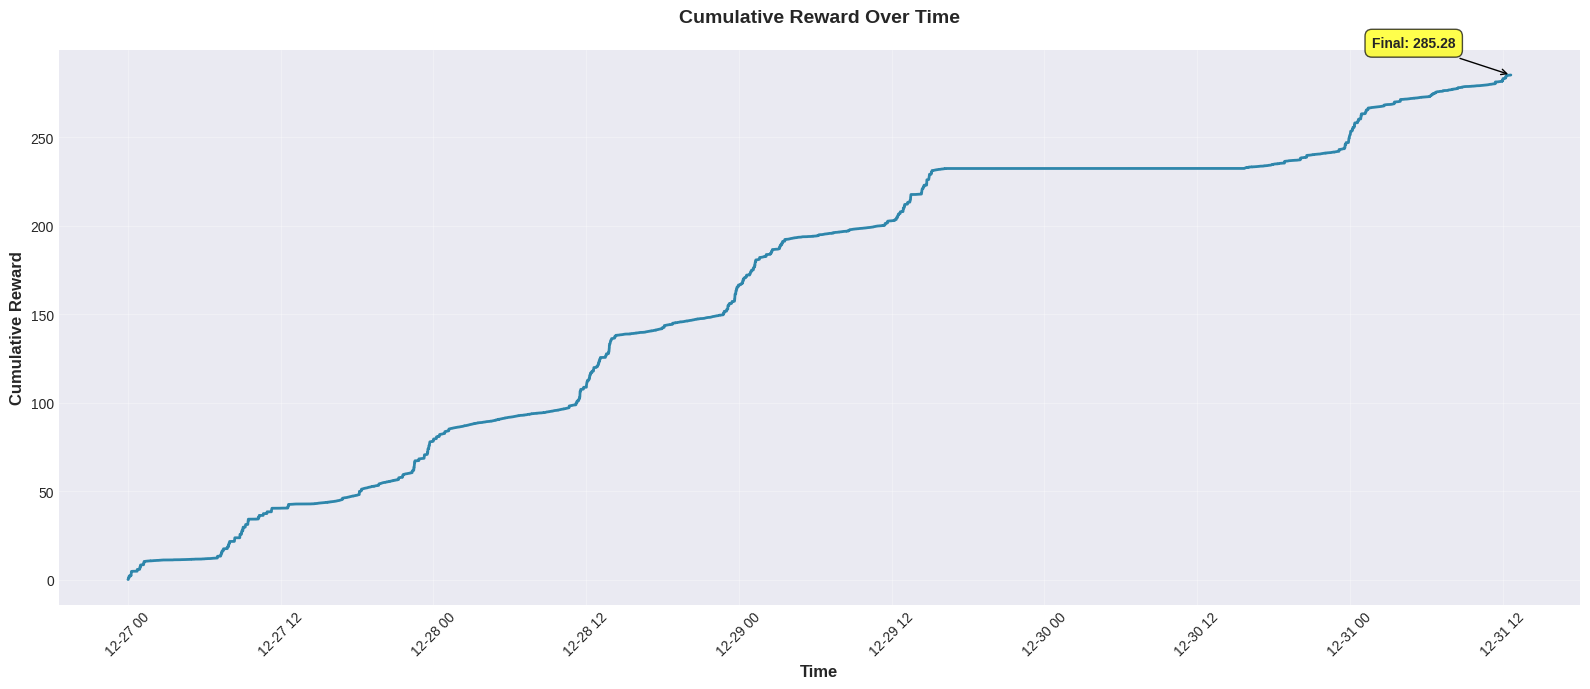

Total cumulative reward: 285.28


In [10]:
# Plot 1: Overall Cumulative Reward Over Time
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(df['_time'], df['cumulative_reward'], linewidth=2, color='#2E86AB')
ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Reward', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Reward Over Time', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

# Add final value annotation
final_reward = df['cumulative_reward'].iloc[-1]
ax.annotate(f'Final: {final_reward:.2f}',
            xy=(df['_time'].iloc[-1], final_reward),
            xytext=(-100, 20),
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
            fontsize=10,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()

print(f"Total cumulative reward: {final_reward:.2f}")

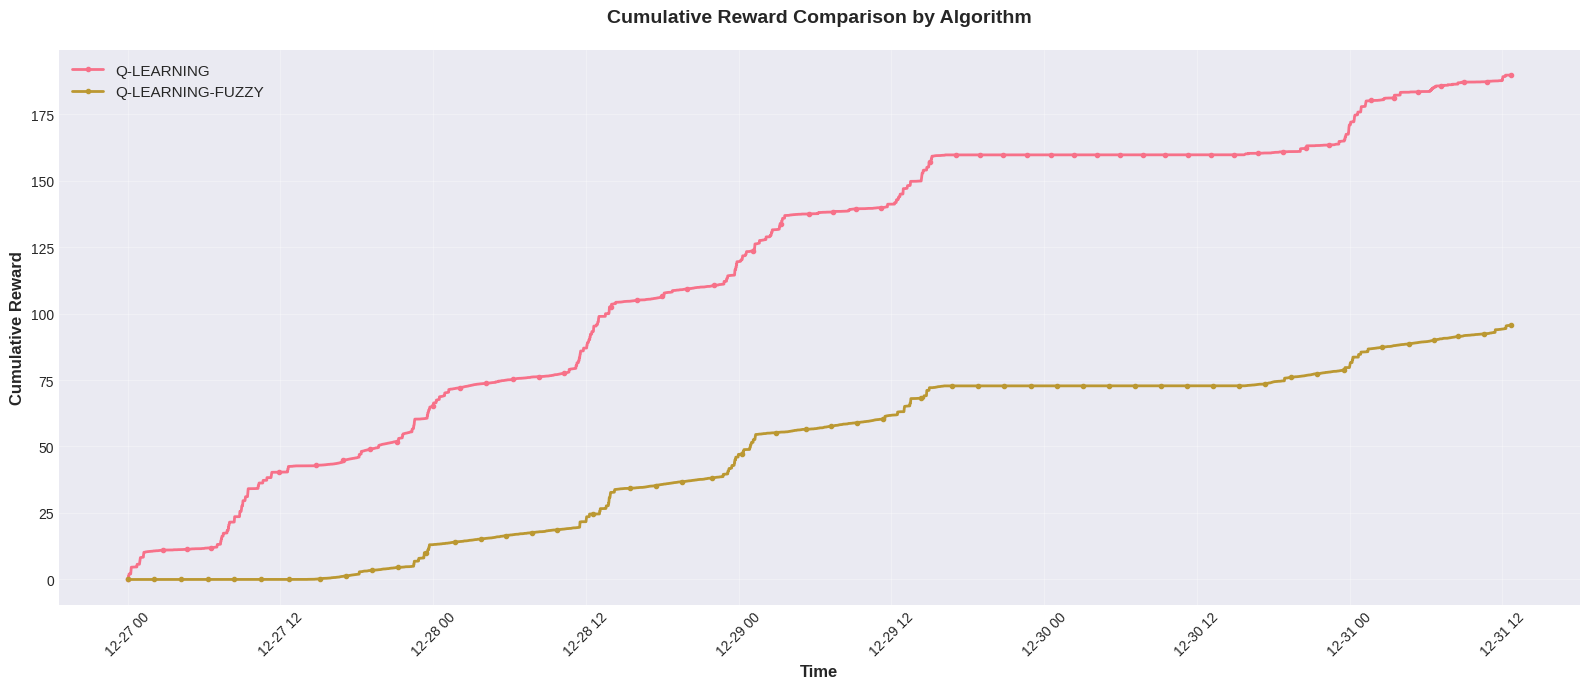

In [11]:
# Plot 2: Cumulative Reward by Algorithm (if applicable)
if 'algorithm' in df.columns and df['algorithm'].nunique() > 1:
    fig, ax = plt.subplots(figsize=(16, 7))
    
    for algo in df['algorithm'].unique():
        algo_df = df[df['algorithm'] == algo]
        ax.plot(algo_df['_time'], algo_df['cumulative_reward_per_algo'], 
                linewidth=2, label=algo, marker='o', markersize=3, markevery=max(1, len(algo_df)//50))
    
    ax.set_xlabel('Time', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Reward', fontsize=12, fontweight='bold')
    ax.set_title('Cumulative Reward Comparison by Algorithm', fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Single algorithm or no algorithm column found. Skipping comparison plot.")

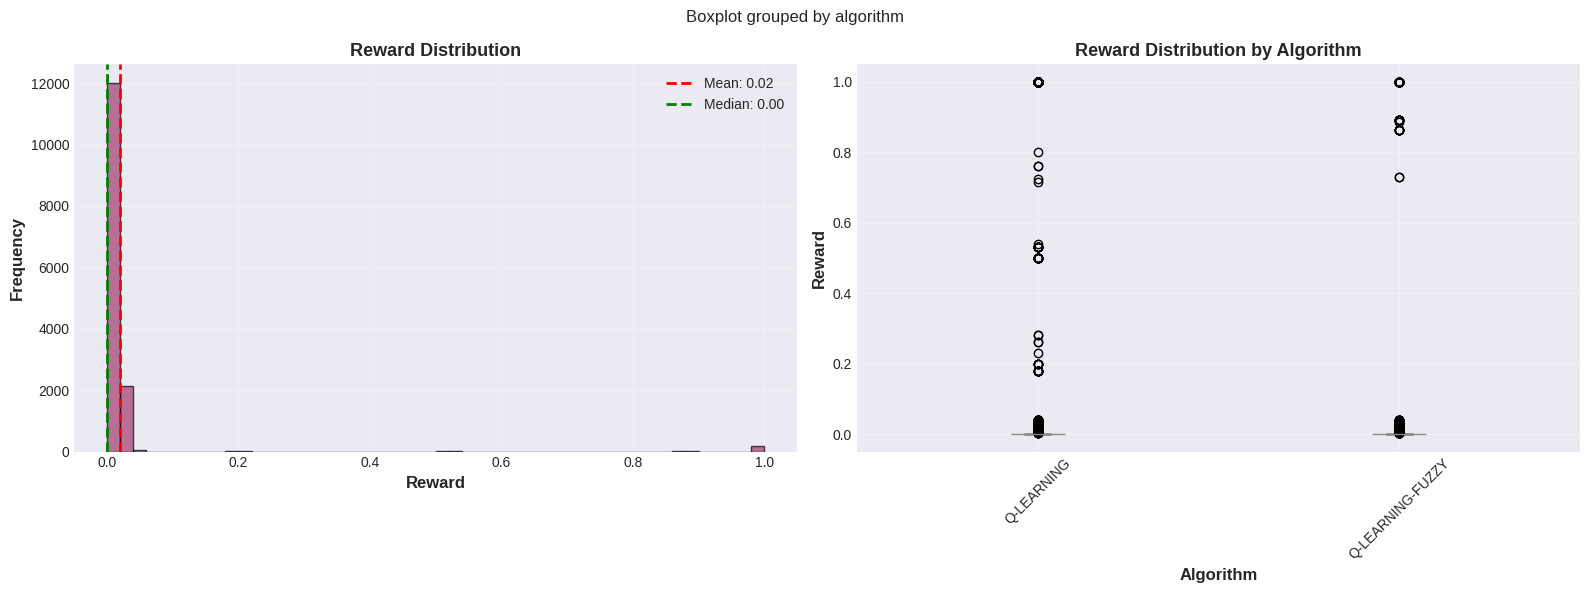

In [12]:
# Plot 3: Reward Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(df['reward'], bins=50, color='#A23B72', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Reward', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Reward Distribution', fontsize=13, fontweight='bold')
axes[0].axvline(df['reward'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["reward"].mean():.2f}')
axes[0].axvline(df['reward'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["reward"].median():.2f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
if 'algorithm' in df.columns and df['algorithm'].nunique() > 1:
    df.boxplot(column='reward', by='algorithm', ax=axes[1], patch_artist=True)
    axes[1].set_xlabel('Algorithm', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Reward', fontsize=12, fontweight='bold')
    axes[1].set_title('Reward Distribution by Algorithm', fontsize=13, fontweight='bold')
    plt.sca(axes[1])
    plt.xticks(rotation=45)
else:
    axes[1].boxplot(df['reward'], patch_artist=True)
    axes[1].set_ylabel('Reward', fontsize=12, fontweight='bold')
    axes[1].set_title('Reward Box Plot', fontsize=13, fontweight='bold')
    axes[1].set_xticklabels(['All Data'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

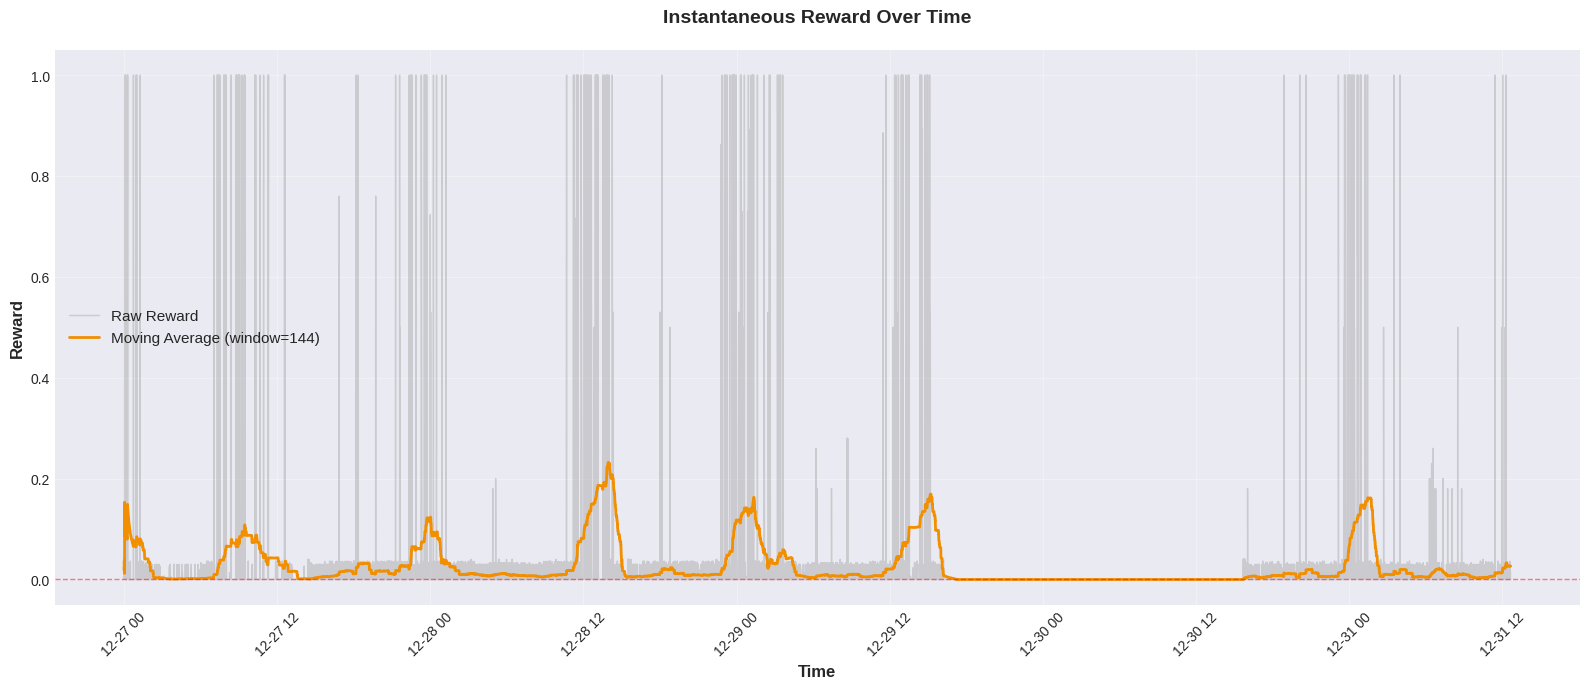

In [13]:
# Plot 4: Instantaneous Reward Over Time (with smoothing)
fig, ax = plt.subplots(figsize=(16, 7))

# Plot raw rewards
ax.plot(df['_time'], df['reward'], alpha=0.3, linewidth=1, label='Raw Reward', color='gray')

# Calculate and plot moving average
window_size = max(50, len(df) // 100)  # Adaptive window size
df['reward_ma'] = df['reward'].rolling(window=window_size, min_periods=1).mean()
ax.plot(df['_time'], df['reward_ma'], linewidth=2, label=f'Moving Average (window={window_size})', color='#F18F01')

ax.set_xlabel('Time', fontsize=12, fontweight='bold')
ax.set_ylabel('Reward', fontsize=12, fontweight='bold')
ax.set_title('Instantaneous Reward Over Time', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.show()

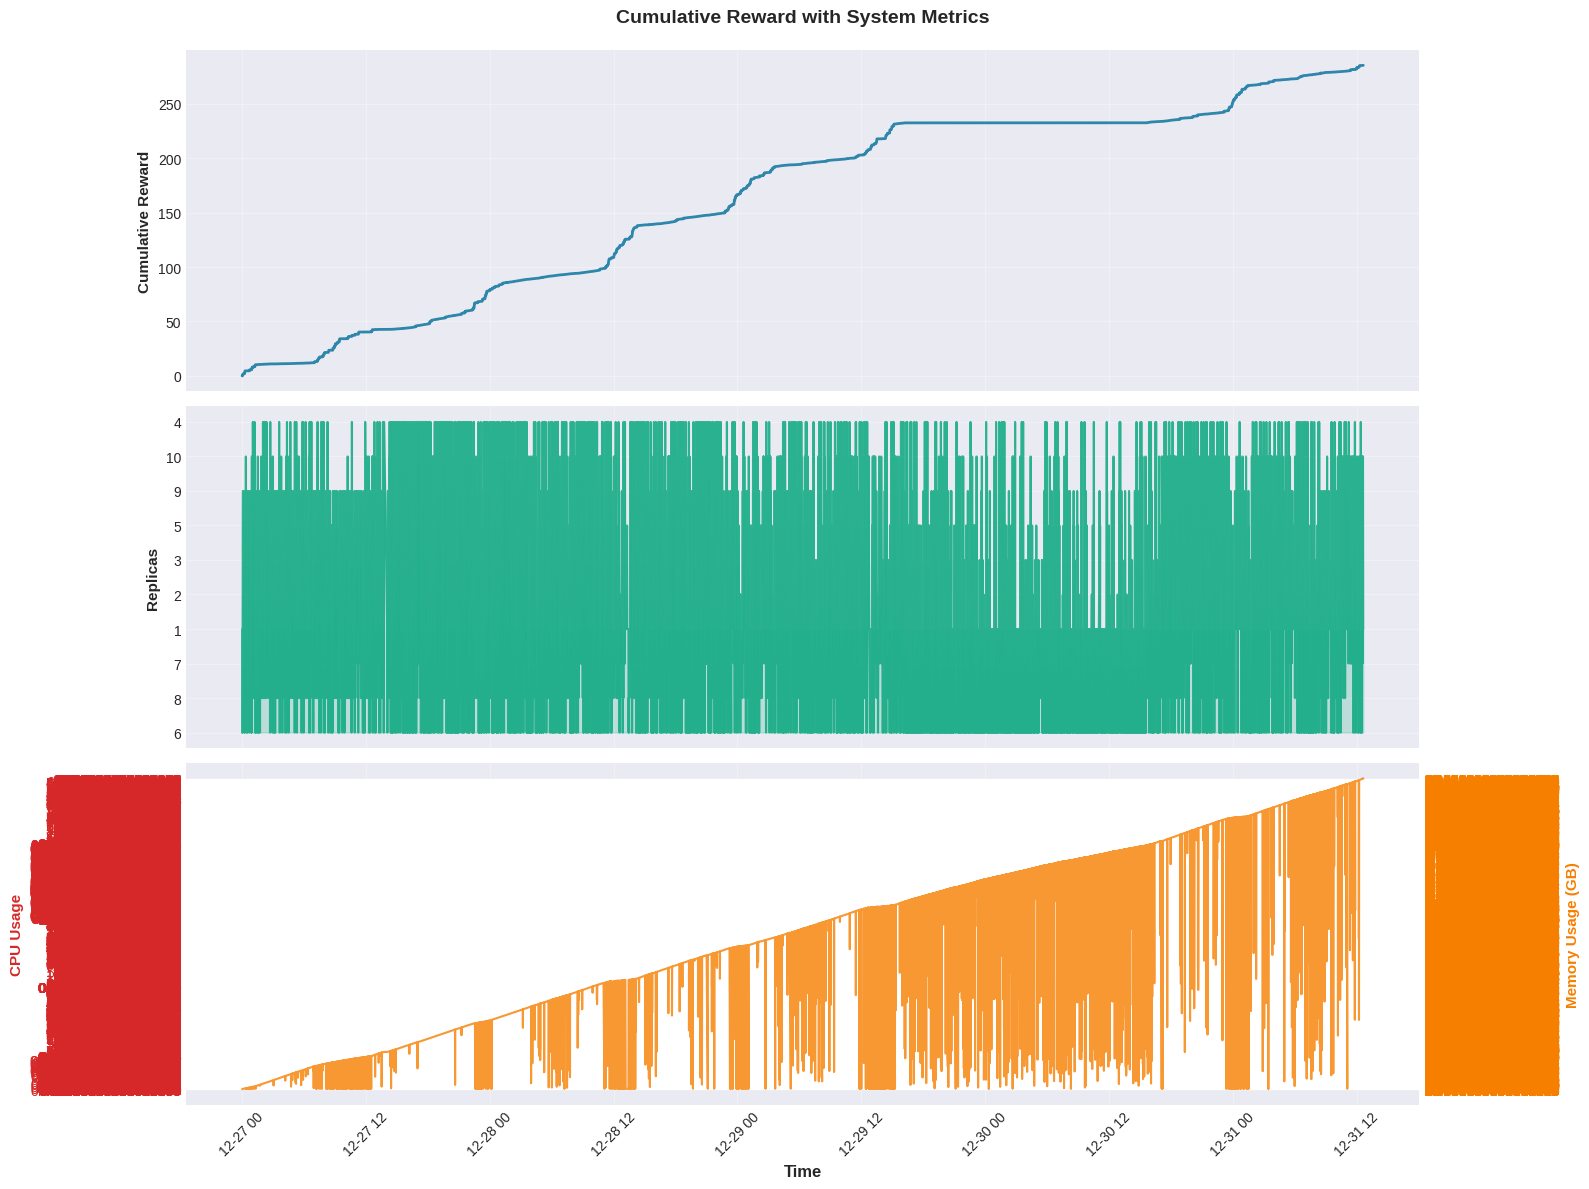

In [14]:
# Plot 5: Cumulative Reward with Performance Metrics
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Cumulative Reward
axes[0].plot(df['_time'], df['cumulative_reward'], linewidth=2, color='#2E86AB')
axes[0].set_ylabel('Cumulative Reward', fontsize=11, fontweight='bold')
axes[0].set_title('Cumulative Reward with System Metrics', fontsize=14, fontweight='bold', pad=20)
axes[0].grid(True, alpha=0.3)

# Replicas over time (if column exists)
if 'replicas' in df.columns or 'replica_state' in df.columns:
    replica_col = 'replicas' if 'replicas' in df.columns else 'replica_state'
    axes[1].plot(df['_time'], df[replica_col], linewidth=1.5, color='#06A77D', alpha=0.8)
    axes[1].set_ylabel('Replicas', fontsize=11, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].fill_between(df['_time'], df[replica_col], alpha=0.2, color='#06A77D')

# CPU and Memory Usage
ax2 = axes[2]
if 'cpu_usage' in df.columns:
    color = '#D62828'
    ax2.plot(df['_time'], df['cpu_usage'], linewidth=1.5, color=color, label='CPU Usage', alpha=0.8)
    ax2.set_ylabel('CPU Usage', fontsize=11, fontweight='bold', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax2.grid(True, alpha=0.3)
    
    if 'memory_usage' in df.columns:
        ax3 = ax2.twinx()
        color = '#F77F00'
        ax3.plot(df['_time'], df['memory_usage'], linewidth=1.5, color=color, label='Memory Usage', alpha=0.8)
        ax3.set_ylabel('Memory Usage (GB)', fontsize=11, fontweight='bold', color=color)
        ax3.tick_params(axis='y', labelcolor=color)

axes[2].set_xlabel('Time', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
# Summary Statistics
print("="*80)
print("CUMULATIVE REWARD ANALYSIS SUMMARY")
print("="*80)

print(f"\nTotal Duration: {df['_time'].max() - df['_time'].min()}")
print(f"Total Steps: {len(df):,}")
print(f"\nFinal Cumulative Reward: {df['cumulative_reward'].iloc[-1]:.2f}")
print(f"Average Reward per Step: {df['reward'].mean():.4f}")
print(f"Median Reward per Step: {df['reward'].median():.4f}")
print(f"Std Dev of Reward: {df['reward'].std():.4f}")
print(f"\nMin Reward: {df['reward'].min():.4f}")
print(f"Max Reward: {df['reward'].max():.4f}")

print(f"\nPositive Rewards: {(df['reward'] > 0).sum():,} ({(df['reward'] > 0).sum()/len(df)*100:.1f}%)")
print(f"Negative Rewards: {(df['reward'] < 0).sum():,} ({(df['reward'] < 0).sum()/len(df)*100:.1f}%)")
print(f"Zero Rewards: {(df['reward'] == 0).sum():,} ({(df['reward'] == 0).sum()/len(df)*100:.1f}%)")

if 'algorithm' in df.columns and df['algorithm'].nunique() > 1:
    print("\n" + "="*80)
    print("PER-ALGORITHM STATISTICS")
    print("="*80)
    for algo in df['algorithm'].unique():
        algo_df = df[df['algorithm'] == algo]
        print(f"\n{algo}:")
        print(f"  Steps: {len(algo_df):,}")
        print(f"  Final Cumulative Reward: {algo_df['cumulative_reward_per_algo'].iloc[-1]:.2f}")
        print(f"  Average Reward: {algo_df['reward'].mean():.4f}")
        print(f"  Median Reward: {algo_df['reward'].median():.4f}")
        print(f"  Std Dev: {algo_df['reward'].std():.4f}")

print("\n" + "="*80)

CUMULATIVE REWARD ANALYSIS SUMMARY

Total Duration: 4 days 12:38:57.383198974
Total Steps: 14,453

Final Cumulative Reward: 285.28
Average Reward per Step: 0.0197
Median Reward per Step: 0.0000
Std Dev of Reward: 0.1164

Min Reward: 0.0000
Max Reward: 1.0000

Positive Rewards: 3,011 (20.8%)
Negative Rewards: 0 (0.0%)
Zero Rewards: 11,442 (79.2%)

PER-ALGORITHM STATISTICS

Q-LEARNING:
  Steps: 7,352
  Final Cumulative Reward: 189.68
  Average Reward: 0.0258
  Median Reward: 0.0000
  Std Dev: 0.1374

Q-LEARNING-FUZZY:
  Steps: 7,101
  Final Cumulative Reward: 95.61
  Average Reward: 0.0135
  Median Reward: 0.0000
  Std Dev: 0.0891

